<a href="https://colab.research.google.com/github/shellyarbel/I2CS_Ex1/blob/master/league_of_legends_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 1: Data Exploration and Initial Understanding
Dataset Description: The data was taken from 'League of Legends' games at the 'Diamond' rank. The table contains statistics collected during the first 10 minutes of approximately 10,000 games. Each row represents a single game, and the columns represent metrics such as: Gold amount, Kills, and Experience points.

In [ ]:
import pandas as pd
df = pd.read_csv('high_diamond_ranked_10min.csv')
print("Shape of the data:", df.shape)
df.head()
df.info()

Shape of the data: (9879, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 98

### Observations from Section 1:

**Target Variable:** Our target for prediction is 'blueWins' (1 for a win, 0 for a loss).

**Data Types:** All features are numerical (int64 or float64), which is ideal for mathematical modeling and avoids the need for complex string-to-number conversions.

**Data Quality:** Based on the info() output, there are zero missing values (nulls) in the entire dataset, ensuring high data integrity.

# Section 2: Data Cleaning and Preprocessing
Data Cleaning: Column names were renamed for convenience, and the unique identifier column (gameId) was removed as it is irrelevant for prediction. Since the dataset consists of numerical values (int/float) and does not include categorical text columns (String), no conversion process to numbers was required.

In [ ]:
cols_to_drop = ['gameId', 'blueGoldPerMin', 'blueCSPerMin', 'redGoldPerMin', 'redCSPerMin']
df = df.drop(columns=cols_to_drop)
df = df.rename(columns={'blueWardsPlaced': 'blue_wards','blueWardsDestroyed': 'blue_wards_destroyed','blueTotalGold': 'blue_gold','blueTotalExperience': 'blue_experience','blueKills': 'blue_kills'})
print("Missing values count per column:")
print(df.isnull().sum().sum())
pd.set_option('display.max_columns', None)
print("\nFirst 5 rows with ALL columns:")
df.head()

Missing values count per column:
0

First 5 rows with ALL columns:


,blueWins,blue_wards,blue_wards_destroyed,blueFirstBlood,blue_kills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blue_gold,blueAvgLevel,blue_experience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff
0,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8
1,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173
2,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033
3,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7
4,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230


### Cleaning Summary:

**Dropped:** The 'gameId' column was removed to prevent the model from learning false patterns from random ID numbers.

Renamed: Key columns were renamed to follow a consistent naming convention.

**Verified:** We confirmed that the dataset is clean with 0 missing values, so no further filling or deleting of rows is needed.

# Section 3: Data Visualization

Visualizing the data allows us to see patterns and correlations that numbers alone cannot show. In this section, we will generate:
1. **Histogram:** To understand the distribution of Gold accumulated by the blue team.
2. **Scatter Plot:** To examine the direct correlation between Kills and Gold.


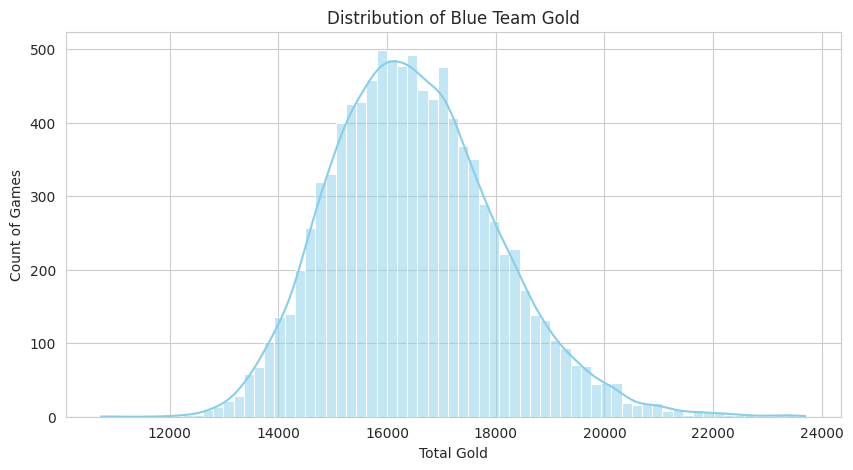

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='blue_gold', kde=True, color='skyblue')
plt.title('Distribution of Blue Team Gold')
plt.xlabel('Total Gold')
plt.ylabel('Count of Games')
plt.show()


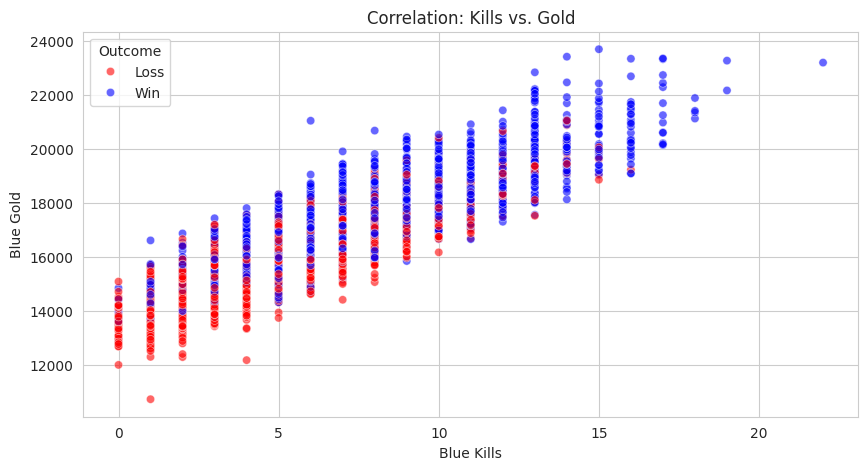

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df,x='blue_kills',y='blue_gold',hue=df['blueWins'].replace({0: 'Loss', 1: 'Win'}),palette={'Loss': 'red', 'Win': 'blue'},alpha=0.6)
plt.title('Correlation: Kills vs. Gold')
plt.xlabel('Blue Kills')
plt.ylabel('Blue Gold')
plt.legend(title='Outcome')
plt.show()

### Key Insights from Visualizations:

1. **Gold Distribution (Histogram):** The data follows a **Normal Distribution** (Bell Curve). This indicates that the dataset is balanced and behaves naturally, without significant outliers or errors.

2. **Kills vs. Gold (Scatter Plot):** We observed a strong **positive linear correlation**. As the number of kills increases, the total gold increases. More importantly, the plot shows a clear cluster of "Wins" (Blue) in the high-gold/high-kills region.

### Note on Line Plot Visualization
The assignment requirements suggest using a Line Plot for data changing over time. However, this dataset represents a **cross-sectional snapshot** of independent matches, all captured specifically at the 10-minute mark.

Since each row represents a distinct game and there is no chronological progression or continuity between them (Game 1 represents a different event than Game 2, not a sequence), a time-series Line Plot is not applicable in this context.